In [120]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [128]:
filenames = ['DiodeUnknownBlank','DiodeUnknown148TEK','DiodeBlackSilver_Si']

def process(file,title='Diode'):
    dat = pd.read_csv(file, sep='\t', header=None)
    dat = dat.drop(columns=[0])
    dat.columns = ['Vin', 'Vout']
    dat.head(5)

    # Take numerical deriative 
    dat['dVout'] = np.gradient(dat['Vout'], dat['Vin'])

    dVout = dat['dVout']

    # Smooth derivative with rolling mean
    s=15
    v = dVout[s]
    dVout = dVout.rolling(window=s).mean()
    dVout[0:s] = v # Fill first s values with first non-NaN value 
    # plt.plot(dat['Vin'], dVout, label=r'$dV_{out}/dV_{in}$',color='navy')

    # print(dVout.isna().sum())

    # Determine 0.9 * Max value
    # Polarity if statement
    if dVout.iloc[0] > dVout.iloc[-1]:
        max_val = dVout.iloc[0:20].mean()
    else:
        max_val = dVout.iloc[-20:].mean()

    threshold = 0.99 * max_val
    # print(f'Max value: {max_val}, Threshold: {threshold}')

    # plt.axhline(threshold, color='red', linestyle='--', label='Threshold')

    # Determine threshold crossing point
    crossing_points = dat[dat['dVout'] >= threshold]
    if dVout.iloc[0] > dVout.iloc[-1]:
        crossing_point = crossing_points.iloc[-1]
    else:
        crossing_point = crossing_points.iloc[0]
    # print(f'Crossing point: Vin={crossing_point["Vin"]}, dVout/dVin={crossing_point["dVout"]}')

    return crossing_point["Vin"], dVout

    # plt.axvline(crossing_point["Vin"], color='black', linestyle='--', label=f'Threshold voltage = {crossing_point["Vin"]:.2f} V')

    # plt.xlabel(r'V_{in} (V)')
    # plt.ylabel(r'$dV_{out}/dV_{in}$')
    # plt.title(title)
    # plt.legend(framealpha=0)
    # plt.show()


In [129]:
process(filenames[1],'Silicon')

(np.float64(0.780192),
 0      0.040925
 1      0.040925
 2      0.040925
 3      0.040925
 4      0.040925
          ...   
 573    0.956605
 574    0.956811
 575    0.956953
 576    0.956950
 577    0.957081
 Name: dVout, Length: 578, dtype: float64)

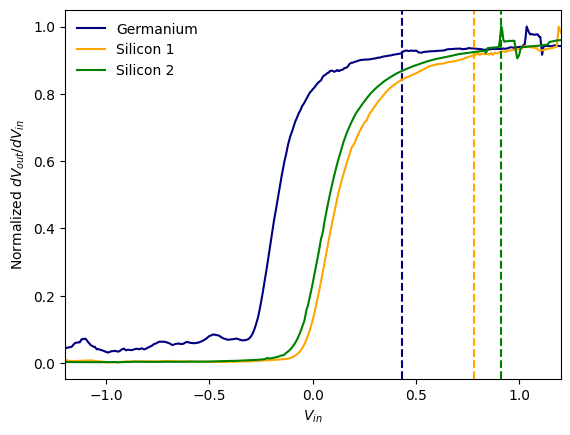

In [148]:
# non dim plot

# normalize by max, then plot dVout vs Vin/Vthreshold
colors = ['navy', 'orange', 'green']
label_list = ['Germanium','Silicon 1', 'Silicon 2']
for file in filenames:
    cross, dVout = process(file)
    Vin = pd.read_csv(file, sep='\t', header=None)[1]
    plt.axvline(np.abs(cross), color=colors[filenames.index(file)], linestyle='--')

    dVout_norm = dVout / dVout.max()

    ind = filenames.index(file)
    if file == filenames[-1]:
        plt.plot(-Vin, dVout_norm, label=label_list[ind], color=colors[ind])

    else:
        plt.plot(Vin, dVout_norm, label=label_list[ind], color=colors[ind])

    plt.legend(framealpha=0)
    plt.xlabel(r'$V_{in}$')
    plt.ylabel(r'Normalized $dV_{out}/dV_{in}$')

    # plt.plot(Vin, dVout_norm)
    plt.xlim(-1.2,1.2)

plt.savefig('Nondim_diodes.png', dpi=300)